In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_excel("New_columns.xlsx")

In [3]:
df.head()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
0,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203,38.98,Pass,Yes,929.0,12870.12,24666.900,0
1,TXN100003,2025-12-27,NaN,Staking,Solana,25571.60,16.49,Institutional,Europe,152,56.57,Pass,No,519.0,5099.70,30685.920,1
2,TXN100004,2025-07-27,Operational,DeFi,Polygon,40219.77,39.93,Retail,Europe,27,82.62,Review,Yes,2002.0,22341.17,48263.724,1
3,TXN100005,2025-08-27,Customer,saving,Polygon,44989.59,18.03,VIP,Europe,177,1.05,Pass,No,3205.0,31676.08,-5000.000,0
4,TXN100006,2025-12-16,Treasury,DeFi,Solana,24827.30,77.33,Institutional,Middle East,202,29.83,Review,No,3439.0,24182.19,29735.688,0


In [4]:
df.tail()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
1995,TXN101997,2025-08-05,Treasury,Supplier,Solana,14100.30,59.02,Retail,Middle East,270,68.20,Pass,Yes,848.0,17649.65,16920.360,0
1996,TXN101998,2025-02-20,Employee,Staking,Polygon,29301.51,92.99,Retail,America,181,94.83,Fail,No,820.0,3953.46,35161.812,1
1997,TXN101999,2025-02-21,Employee,DeFi,Ethereum,42861.13,44.11,VIP,Middle East,222,39.01,Review,No,4650.0,36834.23,51433.356,1
1998,TXN102000,2025-08-14,Customer,NFT,Solana,33225.74,82.92,Retail,Asia,67,61.01,Fail,Yes,1856.0,26083.71,39870.888,1
1999,TXN102001,2025-09-11,Employee,NFT,Polygon,30977.11,100.98,VIP,America,255,73.39,Pass,No,2633.0,23772.50,37172.532,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1995 non-null   object 
 1   Date                        1981 non-null   object 
 2   Wallet_Type                 1921 non-null   object 
 3   Tran_Type                   1974 non-null   object 
 4   Blockchain                  1982 non-null   object 
 5   Amount                      2000 non-null   float64
 6   Gas_Fee_USD                 2000 non-null   float64
 7   Customer_Type               1980 non-null   object 
 8   Region                      1973 non-null   object 
 9   Processing_Time_sec         2000 non-null   int64  
 10  Fraud_Risk_Score            2000 non-null   float64
 11  Compliance_Status           1971 non-null   object 
 12  Marketing_Campaign          1991 non-null   object 
 13  Number_of_Active_Customers  2000 

In [6]:
df.describe()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000
mean,24991.905660,59.419555,153.138500,48.761885,2553.147000,22377.354280,3.667250e+05,0.497000
std,14309.854047,35.038321,85.729091,28.871476,1418.111223,10376.427782,1.470709e+07,0.500116
min,-15000.000000,0.650000,5.000000,0.060000,51.000000,235.680000,-5.555570e+05,0.000000
25%,12216.972500,28.240000,80.000000,23.795000,1359.750000,14427.055000,1.457160e+04,0.000000
50%,24827.300000,59.020000,154.000000,47.930000,2549.500000,22388.270000,2.973569e+04,0.000000
75%,37309.065000,89.817500,225.250000,73.017500,3776.000000,30087.262500,4.477088e+04,1.000000
max,49979.940000,119.970000,300.000000,99.900000,6676.000000,50623.470000,6.576645e+08,1.000000


In [7]:
df.isnull().sum()

Transaction_ID                 5
Date                          19
Wallet_Type                   79
Tran_Type                     26
Blockchain                    18
Amount                         0
Gas_Fee_USD                    0
Customer_Type                 20
Region                        27
Processing_Time_sec            0
Fraud_Risk_Score               0
Compliance_Status             29
Marketing_Campaign             9
Number_of_Active_Customers     0
Daily_Revenue_USD              0
Sales                          0
Sales_Category                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [10]:
df[df.select_dtypes(include="number").columns] = df.select_dtypes(include="number").fillna(df.select_dtypes(include="number").median())

In [11]:
df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").fillna("Unknown")

In [12]:
df = df.drop_duplicates()

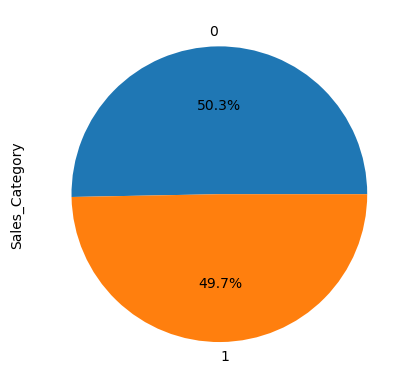

In [13]:
df["Sales_Category"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

In [14]:
X = df[["Amount", "Gas_Fee_USD", "Daily_Revenue_USD"]]

y = df["Sales_Category"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
model = DecisionTreeClassifier(random_state=42)

In [17]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
predictions = model.predict(X_test)

In [19]:
accuracy_score(y_test, predictions)

0.9775

In [20]:
cm = confusion_matrix(y_test, predictions)

pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

,Predicted 0,Predicted 1
Actual 0,199,3
Actual 1,6,192


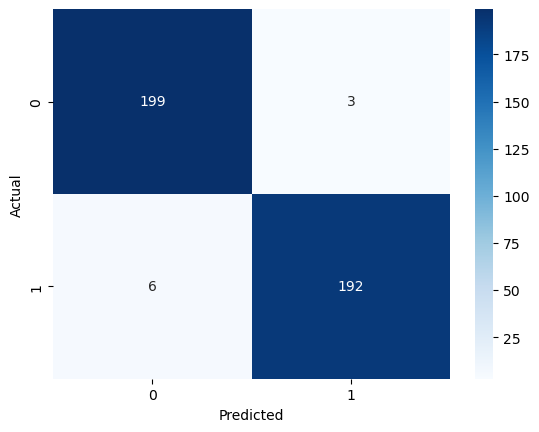

In [21]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
report = classification_report(
    y_test,
    predictions,
    output_dict=True
)

pd.DataFrame(report).transpose()

,precision,recall,f1-score,support
0,0.970732,0.985149,0.977887,202.0000
1,0.984615,0.969697,0.977099,198.0000
accuracy,0.977500,0.977500,0.977500,0.9775
macro avg,0.977674,0.977423,0.977493,400.0000
weighted avg,0.977604,0.977500,0.977497,400.0000


In [23]:
pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

,Feature,Importance
0,Amount,0.971733
1,Gas_Fee_USD,0.014228
2,Daily_Revenue_USD,0.014039


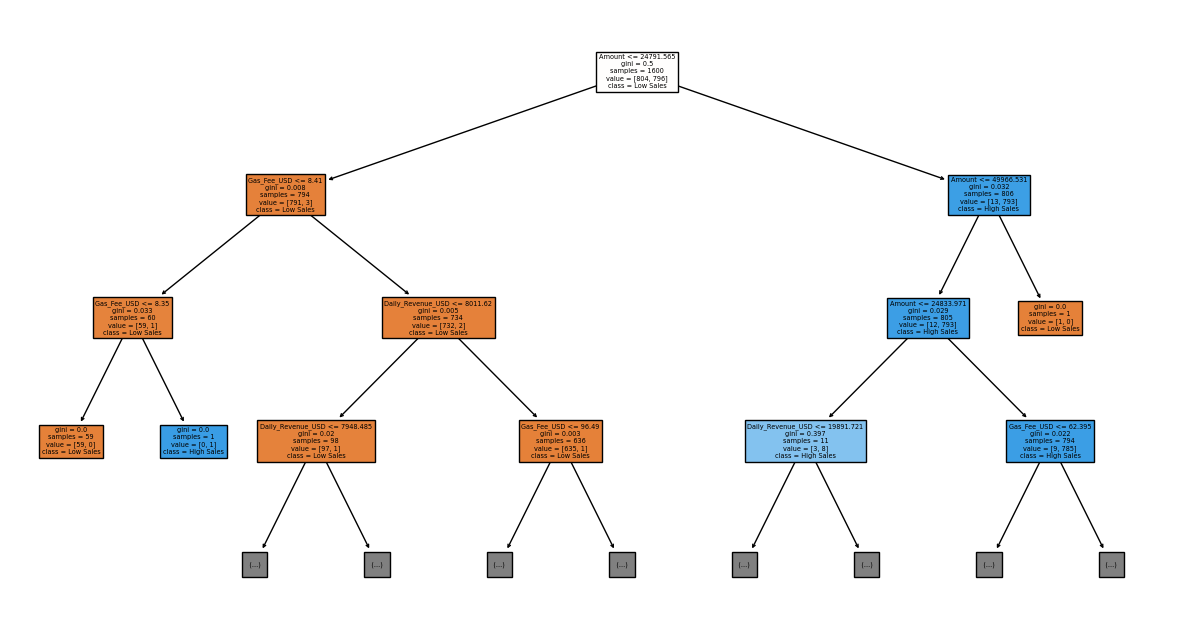

In [24]:
plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low Sales", "High Sales"],
    filled=True,
    max_depth=3
)

plt.show()